# EDA - Clima y calidad del aire global
Proyecto ETL alineado a ODS 13 (Accion por el clima) y ODS 11 (Ciudades y comunidades sostenibles).

Todas las consultas de esta libreta se ejecutan directamente sobre las tablas del datawarehouse
en Supabase (esquema estrella), no sobre el CSV original.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from utils.db_connector import get_engine

engine = get_engine()
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## 1. Calidad de los datos ya cargados
Chequeo rapido de nulos y de la cantidad de filas por tabla, consultado directo a la base.

In [2]:
q = """
select
    (select count(*) from fact_weather_air_quality) as filas_hechos,
    (select count(*) from fact_weather_air_quality where temperature_celsius is null) as nulos_temp,
    (select count(*) from fact_weather_air_quality where air_quality_pm2_5 is null) as nulos_pm25,
    (select count(*) from dim_location) as ciudades,
    (select count(*) from dim_date) as dias
"""
pd.read_sql(q, engine)

,filas_hechos,nulos_temp,nulos_pm25,ciudades,dias
0,164104,0,0,286,845


## 2. Ciudades con peor calidad del aire (PM2.5 promedio)
Pregunta analitica: ¿que ciudades del dataset tienen los niveles mas altos de material particulado fino?

In [3]:
q = """
select l.location_name, l.country, avg(f.air_quality_pm2_5) as pm25_promedio
from fact_weather_air_quality f
join dim_location l on l.location_id = f.location_id
group by l.location_name, l.country
order by pm25_promedio desc
limit 15
"""
top_pm25 = pd.read_sql(q, engine)
top_pm25

,location_name,country,pm25_promedio
0,Kuwait,Kuwait,176.700000
1,Santiago,Chile,136.455185
2,Riyadh,Saudi Arabia,133.461387
3,Jakarta,Indonesia,131.442497
4,Beijing,China,117.845280
5,New Delhi,India,105.392551
6,Kuwait City,Kuwait,92.401403
7,Hanoi,Vietnam,70.488848
8,Seoul,Südkorea,70.200000
9,Nouakchott,Mauritania,65.772363


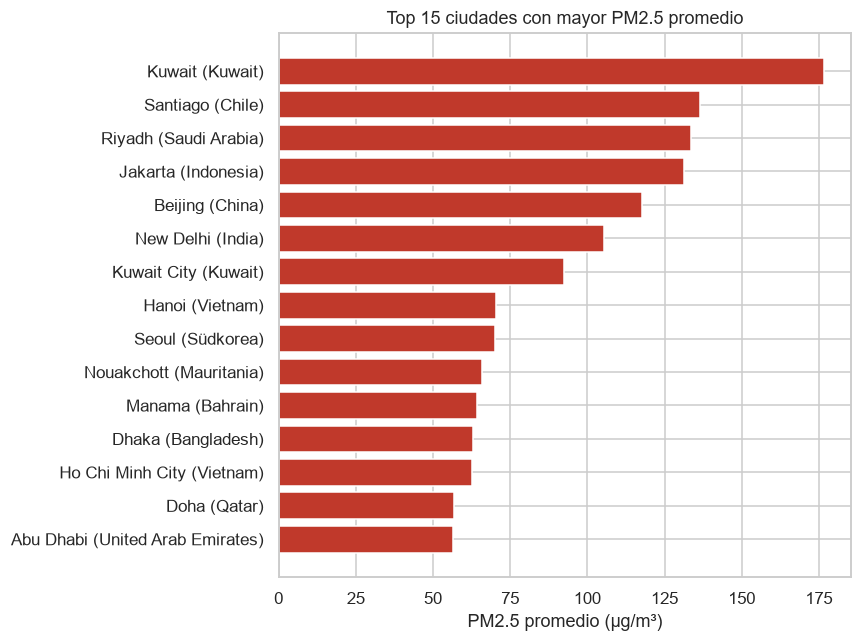

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
etiquetas = top_pm25["location_name"] + " (" + top_pm25["country"] + ")"
ax.barh(etiquetas, top_pm25["pm25_promedio"], color="#c0392b")
ax.invert_yaxis()
ax.set_xlabel("PM2.5 promedio (µg/m³)")
ax.set_title("Top 15 ciudades con mayor PM2.5 promedio")
fig.tight_layout()
fig.savefig("../docs/img/top_pm25.png")
plt.show()

## 3. Relacion entre temperatura y calidad del aire
¿Hay alguna relacion entre la temperatura registrada y el indice de calidad del aire (US EPA)?

In [5]:
q = """
select temperature_celsius, air_quality_us_epa_index, air_quality_pm2_5
from fact_weather_air_quality
where temperature_celsius is not null and air_quality_pm2_5 is not null
"""
clima_aire = pd.read_sql(q, engine)
clima_aire["air_quality_pm2_5"].corr(clima_aire["temperature_celsius"])

np.float64(0.06628869709072673)

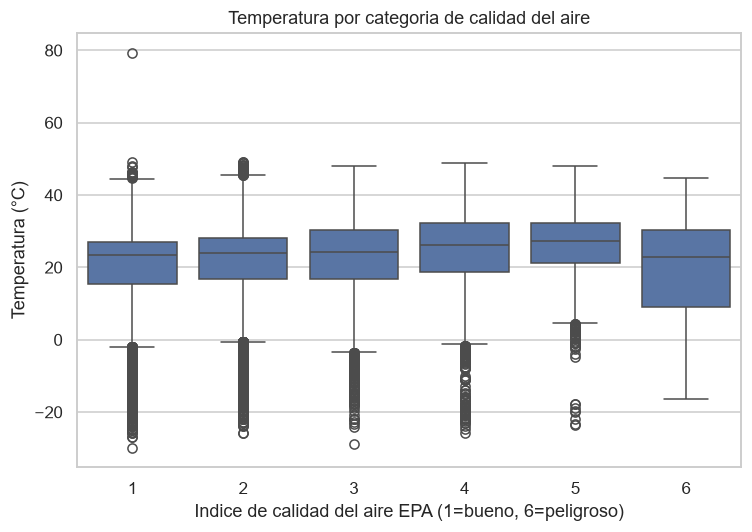

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=clima_aire, x="air_quality_us_epa_index", y="temperature_celsius", ax=ax)
ax.set_xlabel("Indice de calidad del aire EPA (1=bueno, 6=peligroso)")
ax.set_ylabel("Temperatura (°C)")
ax.set_title("Temperatura por categoria de calidad del aire")
fig.tight_layout()
fig.savefig("../docs/img/temp_vs_epa.png")
plt.show()

## 4. Evolucion temporal del PM2.5 promedio global
Tendencia diaria del material particulado fino, promediado entre todas las ciudades del dataset.

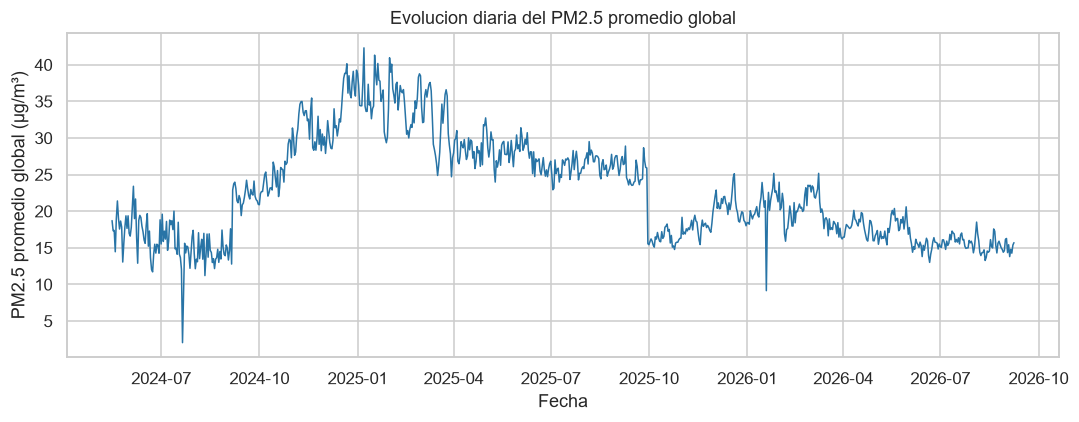

In [7]:
q = """
select d.full_date, avg(f.air_quality_pm2_5) as pm25_promedio
from fact_weather_air_quality f
join dim_date d on d.date_id = f.date_id
group by d.full_date
order by d.full_date
"""
serie_pm25 = pd.read_sql(q, engine)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(serie_pm25["full_date"], serie_pm25["pm25_promedio"], color="#2874a6", linewidth=1)
ax.set_xlabel("Fecha")
ax.set_ylabel("PM2.5 promedio global (µg/m³)")
ax.set_title("Evolucion diaria del PM2.5 promedio global")
fig.tight_layout()
fig.savefig("../docs/img/serie_pm25.png")
plt.show()

## 5. Distribucion de categorias de calidad del aire
¿Que tan frecuente es cada categoria del indice EPA en el mundo?
(1=Bueno, 2=Moderado, 3=Dañino p/ grupos sensibles, 4=Dañino, 5=Muy dañino, 6=Peligroso)

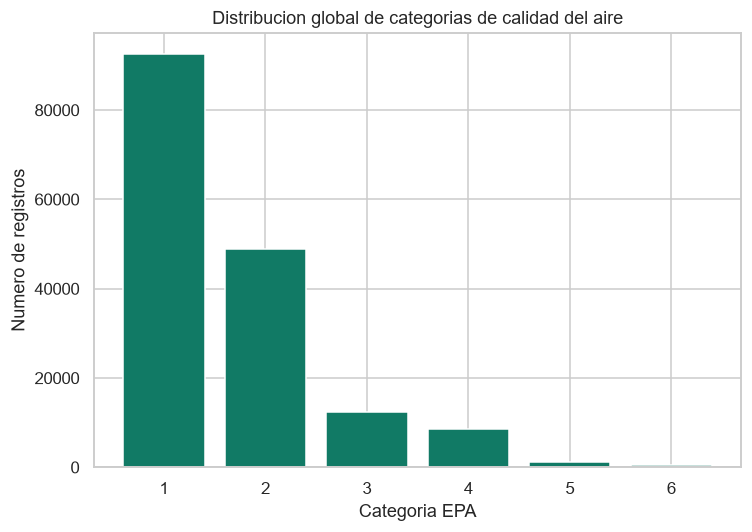

In [8]:
q = """
select air_quality_us_epa_index as categoria, count(*) as registros
from fact_weather_air_quality
group by air_quality_us_epa_index
order by categoria
"""
dist_epa = pd.read_sql(q, engine)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(dist_epa["categoria"].astype(str), dist_epa["registros"], color="#117a65")
ax.set_xlabel("Categoria EPA")
ax.set_ylabel("Numero de registros")
ax.set_title("Distribucion global de categorias de calidad del aire")
fig.tight_layout()
fig.savefig("../docs/img/dist_epa.png")
plt.show()

## 6. Correlacion entre variables climaticas y de calidad del aire

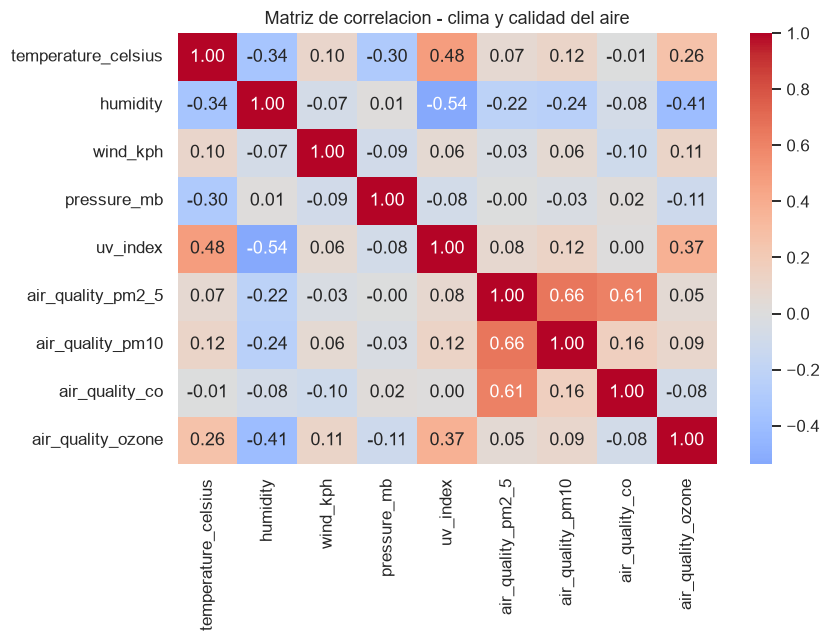

In [9]:
q = """
select temperature_celsius, humidity, wind_kph, pressure_mb, uv_index,
       air_quality_pm2_5, air_quality_pm10, air_quality_co, air_quality_ozone
from fact_weather_air_quality
"""
correl = pd.read_sql(q, engine).corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correl, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlacion - clima y calidad del aire")
fig.tight_layout()
fig.savefig("../docs/img/correlacion.png")
plt.show()

## Conclusiones del EDA

- El dataset permite comparar la calidad del aire entre ciudades capitales de todo el mundo,
  identificando con claridad cuales concentran los niveles mas altos de PM2.5.
- La relacion entre temperatura y calidad del aire no es lineal ni fuerte de forma aislada;
  el indice EPA responde mas a la combinacion de varios contaminantes que a la temperatura por si sola.
- La serie temporal de PM2.5 permite detectar picos puntuales de contaminacion, utiles para un
  sistema de monitoreo tipo el que maneja DAGMA para Cali.
- La matriz de correlacion confirma que PM2.5 y PM10 estan altamente correlacionados entre si
  (misma familia de particulas), mientras que su relacion con variables puramente climaticas
  (viento, presion) es mas debil, lo que sugiere que la contaminacion depende mas de fuentes de
  emision que del clima del dia.